# Global Supplier Disruption Risk Modeling: A Multivariate Analysis

In [ ]:
import pandas as pd

file_path = "data/global_supply_chain_disruption_v1.csv"
df = pd.read_csv(file_path)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Column Names:")
print(df.columns.tolist())

df.head()

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Define Continuous Exogenous Features for PCA
num_cols = [
    'Geopolitical_Risk_Index', 
    'Weather_Severity_Index', 
    'Inflation_Rate_Pct', 
    'Shipping_Cost_USD', 
    'Order_Weight_Kg'
]

# Define Categorical Features
cat_cols = [
    'Origin_City', 
    'Destination_City', 
    'Route_Type', 
    'Transportation_Mode', 
    'Product_Category', 
    'Disruption_Event'
]

# Standardize Matrix
scaler = StandardScaler()
X_num_std = scaler.fit_transform(df[num_cols])

print(f"PCA Input Matrix Shape: {X_num_std.shape}")
print(f"Categorical Variables Included: {len(cat_cols)} columns")

PCA Input Matrix Shape: (10000, 5)
Categorical Variables Included: 6 columns


## Correlation Analysis

Correlation Matrix


,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg
Geopolitical_Risk_Index,1.00,0.01,-0.00,0.09,-0.00
Weather_Severity_Index,0.01,1.00,-0.01,0.02,0.01
Inflation_Rate_Pct,-0.00,-0.01,1.00,-0.01,-0.01
Shipping_Cost_USD,0.09,0.02,-0.01,1.00,0.30
Order_Weight_Kg,-0.00,0.01,-0.01,0.30,1.00


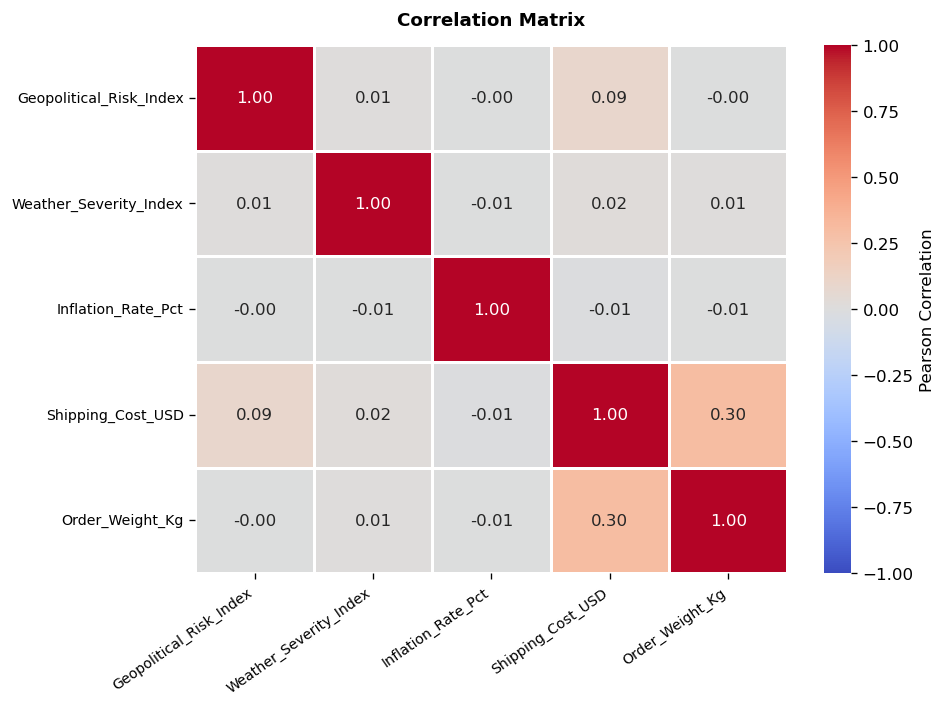

In [41]:
# Correlation Matrix
corr_matrix_pure = df[num_cols].corr()
print("Correlation Matrix")
display(corr_matrix_pure.round(2))

# Plot heatmap
plt.figure(figsize=(8, 6), dpi=120)
sns.heatmap(
    corr_matrix_pure, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    linewidths=0.8,
    cbar_kws={'label': 'Pearson Correlation'}
)

plt.title("Correlation Matrix", fontsize=11, fontweight="bold", pad=12)
plt.xticks(rotation=35, ha="right", fontsize=8.5)
plt.yticks(fontsize=8.5)
plt.tight_layout()
plt.show()

### Key Takeaway

- Heavier orders tend to cost more to ship (0.30), which aligns with standard freight pricing
- Bad weather, political risks, and inflation don't trigger or affect one another (0.00 to 0.02)
- No overlapping data so every metric brings its own unique value to the model

## Principal Component Analysis (Exploratory Variance Decomposition)

In [ ]:
# Covariance Matrix & Eigen-Decomposition
# eigh is used instead of eig because the covariance matrix is symmetric,
# which guarantees real eigenvalues and is numerically more stable.
cov_matrix = np.cov(X_num_std, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort Eigen-pairs Descending
sort_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

# Variance Explained
var_explained = eigenvalues / np.sum(eigenvalues)
cum_var_explained = np.cumsum(var_explained)

print("PCA Variance Explained (Exogenous Factors Only)")
for i in range(len(var_explained)):
    print(f"PC{i+1} ({num_cols[sort_idx[i]]}): {var_explained[i]*100:.2f}% (Cumulative: {cum_var_explained[i]*100:.2f}%)")

### Key Takeaways:

- Geopolitical risk is the single largest factor since it accounts for the biggest share (26.4%) of variation across the dataset
- Political instability, inflation, and shipping costs capture 66.5% of the variance
- Weather has the smallest impact since weather severity accounts for the lowest individual share (13.7%) of overall variation

*Note: this PCA is exploratory — it is used to read variance structure among the continuous exogenous features. The Random Forest model below is trained on the raw (non-reduced) feature set, not on the principal components.*

In [43]:
# Categorical Variables
X_cat_encoded = pd.get_dummies(df[cat_cols], drop_first=True)

# Combine Exogenous Continuous and Categoricals variables
X_full = pd.concat([df[num_cols], X_cat_encoded], axis=1)
y_delay = df['Delay_Days']

# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_full, y_delay)

# Top 10 Drivers
importances = pd.DataFrame({
    'Feature': X_full.columns,
    'Importance_Pct': rf_model.feature_importances_ * 100
}).sort_values(by='Importance_Pct', ascending=False)

print("Top 10 Drivers of Delivery Delays")
display(importances.head(10).style.format({'Importance_Pct': '{:.2f}%'}))

Top 10 Drivers of Delivery Delays


,Feature,Importance_Pct
3,Shipping_Cost_USD,38.70%
4,Order_Weight_Kg,19.04%
0,Geopolitical_Risk_Index,10.08%
19,Transportation_Mode_Sea,9.96%
18,Route_Type_Suez,6.55%
27,Disruption_Event_Severe Weather (Typhoon/Storm),4.66%
26,Disruption_Event_Port Congestion,4.57%
2,Inflation_Rate_Pct,2.53%
1,Weather_Severity_Index,2.28%
23,Product_Category_Raw Materials,0.21%


### Key Takeaway

- Shipment size (19.0%) and cost (38.7%) drive most delays. Together they account for nearly 58% of all delays.
- Geopolitical instability (10.1%) has a bigger impact on schedules than severe weather (4.7%).
- Shipping by sea (10.0%) and taking key maritime routes like the Suez Canal (6.6%) caused the most slowdowns between the various transportation mode.

## Vizualization

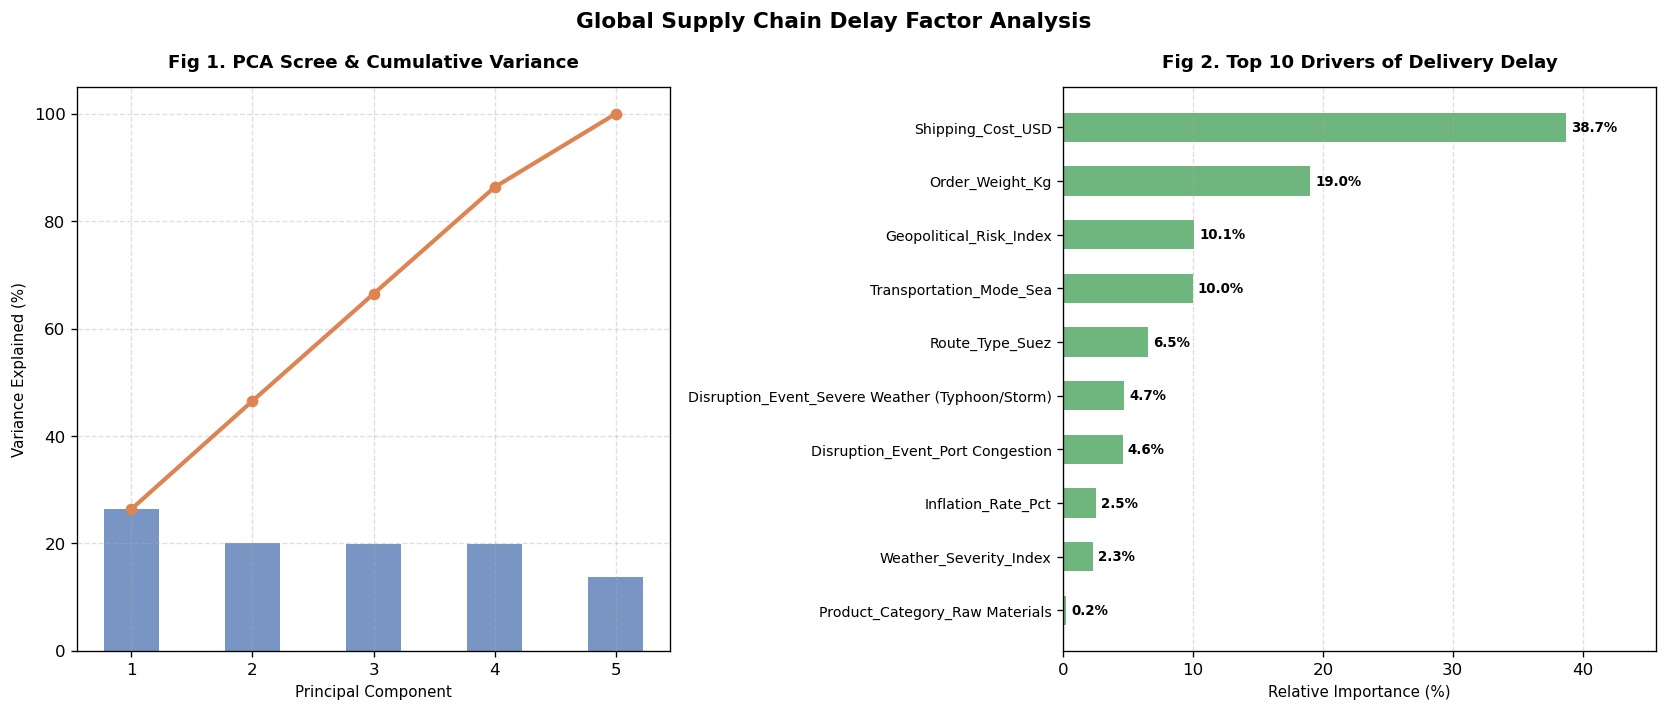

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=120)
plt.subplots_adjust(wspace=0.38)

# Figure 1: PCA & Cumulative Variance
axes[0].bar(range(1, len(var_explained)+1), var_explained*100, alpha=0.75, color='#4c72b0', width=0.45)
axes[0].plot(range(1, len(var_explained)+1), cum_var_explained*100, marker='o', color='#dd8452', linewidth=2.5, markersize=6)
axes[0].set_title('Fig 1. PCA Scree & Cumulative Variance', fontsize=11, fontweight='bold', pad=12)
axes[0].set_xlabel('Principal Component', fontsize=9)
axes[0].set_ylabel('Variance Explained (%)', fontsize=9)
axes[0].set_xticks(range(1, len(var_explained)+1))
axes[0].set_ylim(0, 105)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Figure 2: Top 10 Delay Drivers
top10 = importances.head(10).iloc[::-1]
bars = axes[1].barh(top10['Feature'], top10['Importance_Pct'], color='#55a868', alpha=0.85, height=0.55)

for bar in bars:
    width = bar.get_width()
    axes[1].text(width + 0.4, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
                 va='center', ha='left', fontsize=8, fontweight='bold')

axes[1].set_title('Fig 2. Top 10 Drivers of Delivery Delay', fontsize=11, fontweight='bold', pad=12)
axes[1].set_xlabel('Relative Importance (%)', fontsize=9)
axes[1].set_xlim(0, max(top10['Importance_Pct']) * 1.18)
axes[1].grid(True, linestyle='--', alpha=0.4, axis='x')
axes[1].tick_params(axis='y', labelsize=8.5)

plt.suptitle('Global Supply Chain Delay Factor Analysis', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Conclusion

This analysis combined an exploratory PCA on continuous risk factors with a Random Forest regression to identify the main drivers of supplier delivery delays.

**Key findings:**
- Shipping cost and order weight together account for close to 58% of delay importance, making shipment economics the strongest predictor of delay.
- Geopolitical risk outweighs weather severity as a delay driver, both in the PCA variance decomposition and in the Random Forest feature importances.
- Sea freight and chokepoint routes (e.g. the Suez Canal) are disproportionately associated with delays compared to other transportation modes.

**Possible extensions:**
- Reduce dimensionality by feeding the PCA components (rather than raw features) into the Random Forest, and compare performance.
- Test LDA/QDA to classify shipments into delay-risk categories (e.g. low/medium/high) rather than predicting delay in days.
- Validate the Random Forest with train/test split and cross-validation (the current model is fit on the full dataset for exploratory feature ranking only).